# Helmholtz Equation 1D with PINNs and Dirichlet Boundary Conditions

This code is based on the following tutorial: 

Manuela Bastidas Olivares, Nicolás Guarín-Zapata. (2024). nicoguaro/pinns_mapi-3: Tutorial de PINNs MAPI-3 v1.0 (v1.0). Zenodo. https://doi.org/10.5281/zenodo.11974585

In [36]:
# Esto permite tener gráficos interactivos en
# el caso de correrse en Google Colab
if 'google.colab' in str(get_ipython()):
    %pip install ipympl
    from google.colab import output
    output.enable_custom_widget_manager()

In [37]:
%matplotlib inline

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.autograd import grad

In [39]:
if 'google.colab' in str(get_ipython()):
    style = "https://raw.githubusercontent.com/nicoguaro/pinns_mapi-3/main/notebooks/clean.mplstyle"
else:
    style = "../notebooks/clean.mplstyle"
plt.style.use(style)

In [40]:
class Model(torch.nn.Module):
    def __init__(self, neurons, n_layers, activation=torch.tanh):
        super(Model, self).__init__()
        self.activation = activation
        self.layers = torch.nn.ModuleList()
        self.layers.append(torch.nn.Linear(1, neurons))
        for _ in range(n_layers-2):
            self.layers.append(torch.nn.Linear(neurons, neurons))
        self.layers.append(torch.nn.Linear(neurons, 1))

    def forward(self, x):
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        x = self.layers[-1](x)
        return x

In [41]:
def f_rhs(x, k=1, a=2):
    return (k**2 - a**2 * torch.pi**2) * torch.sin(a * torch.pi * x)


def residual(u, x, f, k=1, a=2):
    du = grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
    ddu = grad(du, x, grad_outputs=torch.ones_like(du), create_graph=True)[0]
    return ddu + k**2 * u - f(x, k, a)

def loss_fn(u_model, x, f, k, a):
    u = u_model(x)
    res = residual(u, x, f, k, a)
    res_MSE = torch.mean(res**2)
    bc = u_model(torch.tensor([-1.]))**2 + u_model(torch.tensor([1.]))**2
    return res_MSE + bc[0]


def train(model, optimizer, scheduler, loss_fn, f, n_pts, iterations, k, a):
    losses = []
    for iteration in range(iterations):  
        optimizer.zero_grad()
        x = torch.FloatTensor(n_pts,1).uniform_(-1., 1.).requires_grad_(True)
        loss = loss_fn(model, x, f, k, a)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']
        
        if iteration % 100 == 0:
            print(f'Iteration {iteration}, Loss {loss.item()}')
            print(f"Epoch {iteration}, LR: {current_lr:.8f}, Loss: {loss.item():.4f}")
    return losses

def train_lbfgs(model, optimizer_lbfgs, loss_fn, f, n_pts, iterations, k, a, x):

    def closure():
        optimizer_lbfgs.zero_grad()
        loss = loss_fn(model, x, f, k, a)
        loss.backward()
        return loss
    
    losses = []
    for iteration in range(iterations): 
        loss = optimizer_lbfgs.step(closure)
        losses.append(loss.item())
        if iteration % 100 == 0:
            print(f"[L-BFGS] Epoch {iteration}, Loss: {loss.item():.4f}")
        
    return losses

def exact_u(x, k=1, a=2):
    return torch.sin(a * torch.pi * x)

In [42]:
nn = 20
nl = 6
model = Model(neurons=nn, n_layers=nl)
for layer in model.layers:
    torch.nn.init.xavier_uniform_(layer.weight, gain=torch.nn.init.calculate_gain('tanh'))  # Xavier/Glorot initialization
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Número de parámetros
sum(p.numel() for p in model.parameters() if p.requires_grad)

1741

In [43]:
n_pts = 1000
iterations = 6000
k = 1
a = 7

In [44]:
start_lr = 1e-3
end_lr = 1e-4
gamma = (end_lr / start_lr) ** (1 / iterations)  # exponential decay factor

# Exponential scheduler
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

In [45]:
losses = train(model, optimizer, scheduler, loss_fn, f_rhs, n_pts, iterations, k=k, a=a)

Iteration 0, Loss 117251.9375
Epoch 0, LR: 0.00099962, Loss: 117251.9375
Iteration 100, Loss 86284.65625
Epoch 100, LR: 0.00096198, Loss: 86284.6562
Iteration 200, Loss 49381.76171875
Epoch 200, LR: 0.00092576, Loss: 49381.7617
Iteration 300, Loss 32008.046875
Epoch 300, LR: 0.00089091, Loss: 32008.0469
Iteration 400, Loss 21681.95703125
Epoch 400, LR: 0.00085737, Loss: 21681.9570
Iteration 500, Loss 18853.978515625
Epoch 500, LR: 0.00082509, Loss: 18853.9785
Iteration 600, Loss 13630.0458984375
Epoch 600, LR: 0.00079402, Loss: 13630.0459
Iteration 700, Loss 13682.6171875
Epoch 700, LR: 0.00076413, Loss: 13682.6172
Iteration 800, Loss 8919.677734375
Epoch 800, LR: 0.00073536, Loss: 8919.6777
Iteration 900, Loss 2504.278076171875
Epoch 900, LR: 0.00070767, Loss: 2504.2781
Iteration 1000, Loss 1376.0872802734375
Epoch 1000, LR: 0.00068103, Loss: 1376.0873
Iteration 1100, Loss 1066.9173583984375
Epoch 1100, LR: 0.00065539, Loss: 1066.9174
Iteration 1200, Loss 679.3134155273438
Epoch 1200,

In [51]:
iterations = 300
optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1, max_iter=20)
xlist = np.linspace(-1., 1., n_pts)
xlist_torch = torch.tensor(xlist, dtype=torch.float32, requires_grad=True).view(-1, 1)
losses = train_lbfgs(model, optimizer_lbfgs, loss_fn, f_rhs, n_pts, iterations, k, a, xlist_torch)

[L-BFGS] Epoch 0, Loss: 11.8559
[L-BFGS] Epoch 100, Loss: 0.0132
[L-BFGS] Epoch 200, Loss: 0.0037


In [52]:
xlist = np.linspace(-1., 1., n_pts)
xlist_torch = torch.tensor(xlist, dtype=torch.float32, requires_grad=True).view(-1, 1)

In [53]:
u_ap = model(xlist_torch)
u_ex = exact_u(xlist_torch, k=k, a=a)

Text(0, 0.5, 'u(x)')

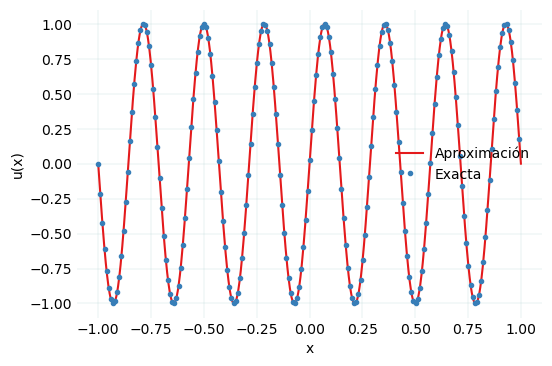

In [54]:
fig, ax = plt.subplots()
plt.plot(xlist, u_ap.detach().numpy())
plt.plot(xlist, u_ex.detach().numpy(), ".", markevery=5)
plt.legend(['Aproximación', 'Exacta'])
plt.xlabel("x")
plt.ylabel("u(x)")

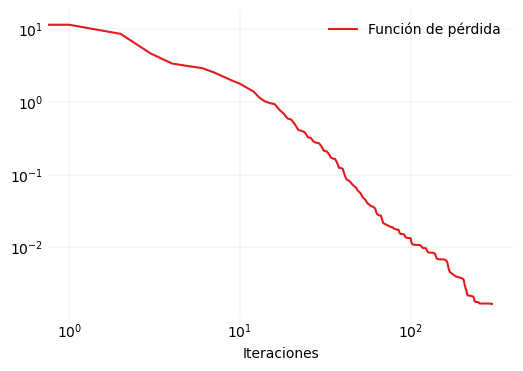

In [55]:
fig, ax = plt.subplots()
plt.loglog(losses)
plt.xlabel("Iteraciones")
plt.legend(['Función de pérdida'])

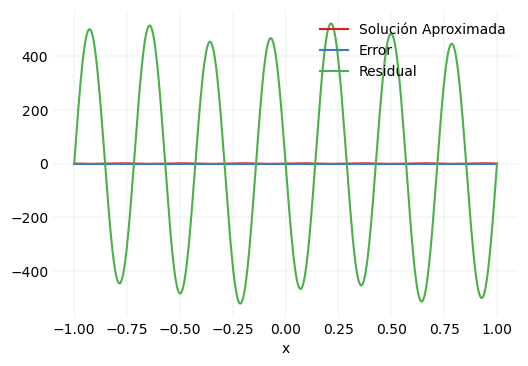

In [56]:
fig, ax = plt.subplots()
plt.plot(xlist, u_ap.detach().numpy())
plt.plot(xlist, (u_ap - u_ex).detach().numpy())
plt.plot(xlist, residual(u_ap, xlist_torch, f_rhs).detach().numpy())
plt.xlabel("x")
plt.legend(["Solución Aproximada", "Error", "Residual"])